In [1]:
# ============================================================
# 📌 YOLO26m Training on VietFood67 Dataset - Kaggle Notebook
# ============================================================
# Purpose: Train YOLO26m on VietFood67 and compare with YOLOv10m
# Dataset: https://www.kaggle.com/datasets/thomasnguyen6868/vietfood68
# Environment: Kaggle Notebook with GPU T4 x2 or P100
# ============================================================

# 🕵️ YOLO26m Training on VietFood67 Dataset
**Goal:** Train YOLO26m and compare performance with YOLOv10m (mAP50 = 0.934)

In [2]:
# NOTE: Do NOT import torch before this cell.
# Only install ultralytics — it will pull compatible dependencies.
# The torchvision warning is harmless and won't block training.
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics", "-q"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

0

In [3]:
import os
import yaml
import shutil
import glob
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# ============================================================
# 📦 DATASET SETUP
# ============================================================
# Actual Kaggle mount path for VietFood68 dataset:
#   /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/
#     ├── images/ (train, valid, test)
#     └── labels/ (train, tvalid, test)   ← note: "tvalid" typo in dataset
# ============================================================

WORK_DIR = "/kaggle/working"
DATASET_BASE = "/kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset"

TRAIN_IMAGES = os.path.join(DATASET_BASE, "images", "train")
VAL_IMAGES   = os.path.join(DATASET_BASE, "images", "valid")
TEST_IMAGES  = os.path.join(DATASET_BASE, "images", "test")

# Verify paths
print("📂 Dataset paths:")
for name, p in [("Train", TRAIN_IMAGES), ("Val", VAL_IMAGES), ("Test", TEST_IMAGES)]:
    if os.path.exists(p):
        n = len(os.listdir(p))
        print(f"   ✅ {name}: {p}  ({n} files)")
    else:
        print(f"   ❌ {name}: {p}  NOT FOUND")

# --- Fix: YOLO auto-resolves labels by replacing "images" → "labels" in path.
# The dataset has "labels/tvalid" instead of "labels/valid", so we create a symlink.
labels_valid_expected = os.path.join(DATASET_BASE, "labels", "valid")
labels_tvalid_actual  = os.path.join(DATASET_BASE, "labels", "tvalid")

if not os.path.exists(labels_valid_expected) and os.path.exists(labels_tvalid_actual):
    # Kaggle input is read-only, so copy labels to working dir instead
    import subprocess
    LABELS_WORK = os.path.join(WORK_DIR, "dataset_labels_fix", "labels", "valid")
    os.makedirs(LABELS_WORK, exist_ok=True)
    subprocess.run(["cp", "-r", labels_tvalid_actual + "/.", LABELS_WORK], check=True)
    print(f"   🔧 Fixed: copied labels/tvalid → {LABELS_WORK}")
    # We'll need to copy images/valid to the same structure so paths align
    IMAGES_WORK_VALID = os.path.join(WORK_DIR, "dataset_labels_fix", "images", "valid")
    os.makedirs(IMAGES_WORK_VALID, exist_ok=True)
    subprocess.run(["cp", "-rs", VAL_IMAGES + "/.", IMAGES_WORK_VALID], check=True)
    # Override VAL path to use the fixed copy
    VAL_IMAGES = IMAGES_WORK_VALID
    print(f"   🔧 Val images symlinked to: {VAL_IMAGES}")
elif os.path.exists(labels_valid_expected):
    print(f"   ✅ labels/valid exists, no fix needed")
else:
    print(f"   ⚠️ Neither labels/valid nor labels/tvalid found")

📂 Dataset paths:
   ✅ Train: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/images/train  (161733 files)
   ✅ Val: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/images/valid  (6602 files)
   ✅ Test: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/images/test  (3284 files)
   ✅ labels/valid exists, no fix needed


In [5]:
# ============================================================
# 68 classes (67 Vietnamese dishes + 1 Human class)
# Using ABSOLUTE paths to avoid YOLO path resolution issues
# ============================================================

CLASS_NAMES = [
    "Banh canh", "Banh chung", "Banh cuon", "Banh khot", "Banh mi",
    "Banh trang", "Banh trang tron", "Banh xeo", "Bo kho", "Bo la lot",
    "Bong cai", "Bun", "Bun bo Hue", "Bun cha", "Bun dau",
    "Bun mam", "Bun rieu", "Ca", "Ca chua", "Ca phao",
    "Ca rot", "Canh", "Cha", "Cha gio", "Chanh",
    "Com", "Com tam", "Con nguoi", "Cu kieu", "Cua",
    "Dau hu", "Dua chua", "Dua leo", "Goi cuon", "Hamburger",
    "Heo quay", "Hu tieu", "Kho qua thit", "Khoai tay chien", "Lau",
    "Long heo", "Mi", "Muc", "Nam", "Oc",
    "Ot chuong", "Pho", "Pho mai", "Rau", "Salad",
    "Thit bo", "Thit ga", "Thit heo", "Thit kho", "Thit nuong",
    "Tom", "Trung", "Xoi", "Banh beo", "Cao lau",
    "Mi Quang", "Com chien duong chau", "Bun cha ca", "Com chien ga",
    "Chao long", "Nom hoa chuoi", "Nui xao bo", "Sup cua"
]

# Build data.yaml with absolute paths (no "path" key)
data_config = {
    "train": TRAIN_IMAGES,
    "val": VAL_IMAGES,
    "test": TEST_IMAGES,
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

data_yaml_path = os.path.join(WORK_DIR, "data.yaml")
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f"\n✅ data.yaml saved to: {data_yaml_path}")
print("   Contents:")
with open(data_yaml_path, 'r') as f:
    print(f.read())


✅ data.yaml saved to: /kaggle/working/data.yaml
   Contents:
names:
- Banh canh
- Banh chung
- Banh cuon
- Banh khot
- Banh mi
- Banh trang
- Banh trang tron
- Banh xeo
- Bo kho
- Bo la lot
- Bong cai
- Bun
- Bun bo Hue
- Bun cha
- Bun dau
- Bun mam
- Bun rieu
- Ca
- Ca chua
- Ca phao
- Ca rot
- Canh
- Cha
- Cha gio
- Chanh
- Com
- Com tam
- Con nguoi
- Cu kieu
- Cua
- Dau hu
- Dua chua
- Dua leo
- Goi cuon
- Hamburger
- Heo quay
- Hu tieu
- Kho qua thit
- Khoai tay chien
- Lau
- Long heo
- Mi
- Muc
- Nam
- Oc
- Ot chuong
- Pho
- Pho mai
- Rau
- Salad
- Thit bo
- Thit ga
- Thit heo
- Thit kho
- Thit nuong
- Tom
- Trung
- Xoi
- Banh beo
- Cao lau
- Mi Quang
- Com chien duong chau
- Bun cha ca
- Com chien ga
- Chao long
- Nom hoa chuoi
- Nui xao bo
- Sup cua
nc: 68
test: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/images/test
train: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/images/train
val: /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/image

In [6]:
# ============================================================
# ⚙️ TRAINING HYPERPARAMETERS
# ============================================================
# Matching YOLOv10m training setup from the project for fair comparison
# Project used: YOLOv10m + SGD optimizer
# We will train: YOLO26m + SGD and YOLO26m + MuSGD (new in YOLO26)
# ============================================================

TRAINING_CONFIG = {
    # --- Model ---
    "model_variant": "yolo26m.pt",     # Medium variant (same scale as YOLOv10m)
    
    # --- Training ---
    # NOTE: Dataset on Kaggle is ALREADY augmented offline (161k images from ~30k originals)
    #       So we reduce online augmentation to avoid double-augmentation.
    #       Also adjusted epochs/batch to fit Kaggle 12h GPU session limit.
    "epochs": 50,                       # Reduced (161k images = large dataset)
    "imgsz": 640,                       # Image size (same as project)
    "batch": 16,                        # T4 16GB: batch 32 causes OOM, 16 is safe
    "patience": 15,                     # Early stopping patience
    
    # --- Optimizer (SGD to match original project) ---
    "optimizer": "SGD",                 # Use SGD for fair comparison
    "lr0": 0.01,                        # Initial learning rate
    "lrf": 0.01,                        # Final learning rate factor
    "momentum": 0.937,                  # SGD momentum
    "weight_decay": 0.0005,             # Weight decay
    
    # --- Augmentation (REDUCED — dataset already augmented offline) ---
    "hsv_h": 0.01,                      # Reduced (brightness already augmented)
    "hsv_s": 0.3,                       # Reduced
    "hsv_v": 0.2,                       # Reduced (brightness already augmented)
    "degrees": 0.0,                     # No rotation
    "translate": 0.05,                  # Minimal translation
    "scale": 0.2,                       # Reduced (cropping already applied)
    "fliplr": 0.5,                      # Keep horizontal flip (lightweight)
    "flipud": 0.0,                      # No vertical flip
    "mosaic": 0.3,                      # Reduced significantly (mosaic already applied offline)
    "mixup": 0.0,                       # No mixup
    
    # --- Device ---
    "device": 0 if torch.cuda.is_available() else "cpu",
    "workers": 4,
    
    # --- Saving ---
    "project": os.path.join(WORK_DIR, "runs"),
    "name": "yolo26m_vietfood67_sgd",
    "save_period": 10,                  # Save checkpoint every N epochs
    "exist_ok": True,
}

print("⚙️ Training Configuration:")
for k, v in TRAINING_CONFIG.items():
    print(f"   {k}: {v}")

⚙️ Training Configuration:
   model_variant: yolo26m.pt
   epochs: 50
   imgsz: 640
   batch: 16
   patience: 15
   optimizer: SGD
   lr0: 0.01
   lrf: 0.01
   momentum: 0.937
   weight_decay: 0.0005
   hsv_h: 0.01
   hsv_s: 0.3
   hsv_v: 0.2
   degrees: 0.0
   translate: 0.05
   scale: 0.2
   fliplr: 0.5
   flipud: 0.0
   mosaic: 0.3
   mixup: 0.0
   device: 0
   workers: 4
   project: /kaggle/working/runs
   name: yolo26m_vietfood67_sgd
   save_period: 10
   exist_ok: True


In [7]:
# ============================================================
# 🚀 TRAINING - YOLO26m with SGD (fair comparison with YOLOv10m)
# ============================================================
# Resume support: Upload last.pt from previous session as a Kaggle dataset,
# the script will auto-detect and resume training.
#
# Steps to resume:
#   1. Download last.pt from previous session output
#   2. Create a new Kaggle dataset (e.g. "yolo26-checkpoint") and upload last.pt
#   3. Add that dataset to this notebook via "Add Data"
#   4. Run — script will find it automatically
# ============================================================

# --- Search for last.pt to resume from ---
RESUME_CHECKPOINT = None

# Search locations (in priority order)
search_paths = [
    # 1. Previous run output in working dir
    os.path.join(TRAINING_CONFIG["project"], TRAINING_CONFIG["name"], "weights", "last.pt"),
    # 2. Uploaded as Kaggle dataset (search all input dirs)
]

# Check fixed paths first
for p in search_paths:
    if os.path.exists(p):
        RESUME_CHECKPOINT = p
        break

# Search all Kaggle input directories for last.pt
if RESUME_CHECKPOINT is None:
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            if f == "last.pt":
                RESUME_CHECKPOINT = os.path.join(root, f)
                break
        if RESUME_CHECKPOINT:
            break

print("=" * 60)
if RESUME_CHECKPOINT:
    print(f"🔄 RESUMING training from: {RESUME_CHECKPOINT}")
    print("=" * 60)
    
    model_sgd = YOLO(RESUME_CHECKPOINT)
    
    start_time = time.time()
    results_sgd = model_sgd.train(resume=True)
else:
    print("🚀 Starting FRESH YOLO26m training with SGD optimizer")
    print("=" * 60)
    
    model_sgd = YOLO(TRAINING_CONFIG["model_variant"])
    
    start_time = time.time()
    results_sgd = model_sgd.train(
        data=data_yaml_path,
        epochs=TRAINING_CONFIG["epochs"],
        imgsz=TRAINING_CONFIG["imgsz"],
        batch=TRAINING_CONFIG["batch"],
        patience=TRAINING_CONFIG["patience"],
        optimizer=TRAINING_CONFIG["optimizer"],
        lr0=TRAINING_CONFIG["lr0"],
        lrf=TRAINING_CONFIG["lrf"],
        momentum=TRAINING_CONFIG["momentum"],
        weight_decay=TRAINING_CONFIG["weight_decay"],
        hsv_h=TRAINING_CONFIG["hsv_h"],
        hsv_s=TRAINING_CONFIG["hsv_s"],
        hsv_v=TRAINING_CONFIG["hsv_v"],
        degrees=TRAINING_CONFIG["degrees"],
        translate=TRAINING_CONFIG["translate"],
        scale=TRAINING_CONFIG["scale"],
        fliplr=TRAINING_CONFIG["fliplr"],
        flipud=TRAINING_CONFIG["flipud"],
        mosaic=TRAINING_CONFIG["mosaic"],
        mixup=TRAINING_CONFIG["mixup"],
        device=TRAINING_CONFIG["device"],
        workers=TRAINING_CONFIG["workers"],
        project=TRAINING_CONFIG["project"],
        name=TRAINING_CONFIG["name"],
        save_period=TRAINING_CONFIG["save_period"],
        exist_ok=TRAINING_CONFIG["exist_ok"],
        verbose=True,
    )

sgd_training_time = time.time() - start_time
print(f"\n⏱️ Training completed in {sgd_training_time/3600:.2f} hours")

🔄 RESUMING training from: /kaggle/input/datasets/nguyenvutl/epochs34-39-yolov26m-food-detection/runs/yolo26m_vietfood67_sgd/weights/last.pt
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [8]:
# ============================================================
# 📊 VALIDATION - Evaluate on test set
# ============================================================

print("=" * 60)
print("📊 Evaluating YOLO26m (SGD) on test set")
print("=" * 60)

best_sgd_path = os.path.join(
    TRAINING_CONFIG["project"], TRAINING_CONFIG["name"], "weights", "best.pt"
)
model_sgd_best = YOLO(best_sgd_path)

val_results_sgd = model_sgd_best.val(
    data=data_yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=TRAINING_CONFIG["device"],
    verbose=True,
)

print("\n📊 YOLO26m (SGD) Test Results:")
print(f"   mAP50:    {val_results_sgd.box.map50:.4f}")
print(f"   mAP50-95: {val_results_sgd.box.map:.4f}")
print(f"   Precision: {val_results_sgd.box.mp:.4f}")
print(f"   Recall:    {val_results_sgd.box.mr:.4f}")

📊 Evaluating YOLO26m (SGD) on test set
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26m summary (fused): 132 layers, 20,401,880 parameters, 0 gradients, 68.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.2±0.3 ms, read: 8.5±7.1 MB/s, size: 52.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/labels/test... 3284 images, 75 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3284/3284 191.9it/s 17.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thomasnguyen6868/vietfood68/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 206/206 2.6it/s 1:20
                   all       3284       5670       0.92       0.92      0.958       0.84
             Banh canh         58   

In [9]:
# ============================================================
# 🚀 TRAINING - YOLO26m with MuSGD (new optimizer in YOLO26)
# ============================================================
# Uncomment this cell to also train with MuSGD for additional comparison

# print("=" * 60)
# print("🚀 Starting YOLO26m training with MuSGD optimizer")
# print("=" * 60)
#
# model_musgd = YOLO("yolo26m.pt")
#
# start_time_musgd = time.time()
#
# results_musgd = model_musgd.train(
#     data=data_yaml_path,
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     patience=20,
#     optimizer="MuSGD",         # <-- New hybrid optimizer in YOLO26
#     lr0=0.01,
#     lrf=0.01,
#     device=TRAINING_CONFIG["device"],
#     workers=4,
#     project=os.path.join(WORK_DIR, "runs"),
#     name="yolo26m_vietfood67_musgd",
#     save_period=10,
#     exist_ok=True,
#     verbose=True,
# )
#
# musgd_training_time = time.time() - start_time_musgd
# print(f"\n⏱️ MuSGD Training completed in {musgd_training_time/3600:.2f} hours")
#
# # Validate MuSGD model
# best_musgd_path = os.path.join(WORK_DIR, "runs", "yolo26m_vietfood67_musgd", "weights", "best.pt")
# model_musgd_best = YOLO(best_musgd_path)
# val_results_musgd = model_musgd_best.val(data=data_yaml_path, split="test", imgsz=640, batch=16)
# print(f"\n📊 YOLO26m (MuSGD) - mAP50: {val_results_musgd.box.map50:.4f}")

In [10]:
# ============================================================
# 📊 COMPARISON: YOLOv10m vs YOLO26m
# ============================================================

print("=" * 60)
print("📊 MODEL COMPARISON SUMMARY")
print("=" * 60)

comparison_data = {
    "Metric": ["mAP50", "mAP50-95", "Precision", "Recall", "Optimizer", "Training Time (h)"],
    "YOLOv10m (Project)": [
        0.934,          # mAP50 from the project README
        "N/A",          # mAP50-95 not reported
        "N/A",          # Precision not reported
        "N/A",          # Recall not reported
        "SGD",
        "N/A"
    ],
    "YOLO26m (SGD)": [
        f"{val_results_sgd.box.map50:.4f}",
        f"{val_results_sgd.box.map:.4f}",
        f"{val_results_sgd.box.mp:.4f}",
        f"{val_results_sgd.box.mr:.4f}",
        "SGD",
        f"{sgd_training_time/3600:.2f}"
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Save comparison to CSV
comparison_csv_path = os.path.join(WORK_DIR, "model_comparison.csv")
df_comparison.to_csv(comparison_csv_path, index=False)
print(f"\n💾 Comparison saved to: {comparison_csv_path}")

📊 MODEL COMPARISON SUMMARY
           Metric YOLOv10m (Project) YOLO26m (SGD)
            mAP50              0.934        0.9581
         mAP50-95                N/A        0.8396
        Precision                N/A        0.9204
           Recall                N/A        0.9199
        Optimizer                SGD           SGD
Training Time (h)                N/A         11.34

💾 Comparison saved to: /kaggle/working/model_comparison.csv


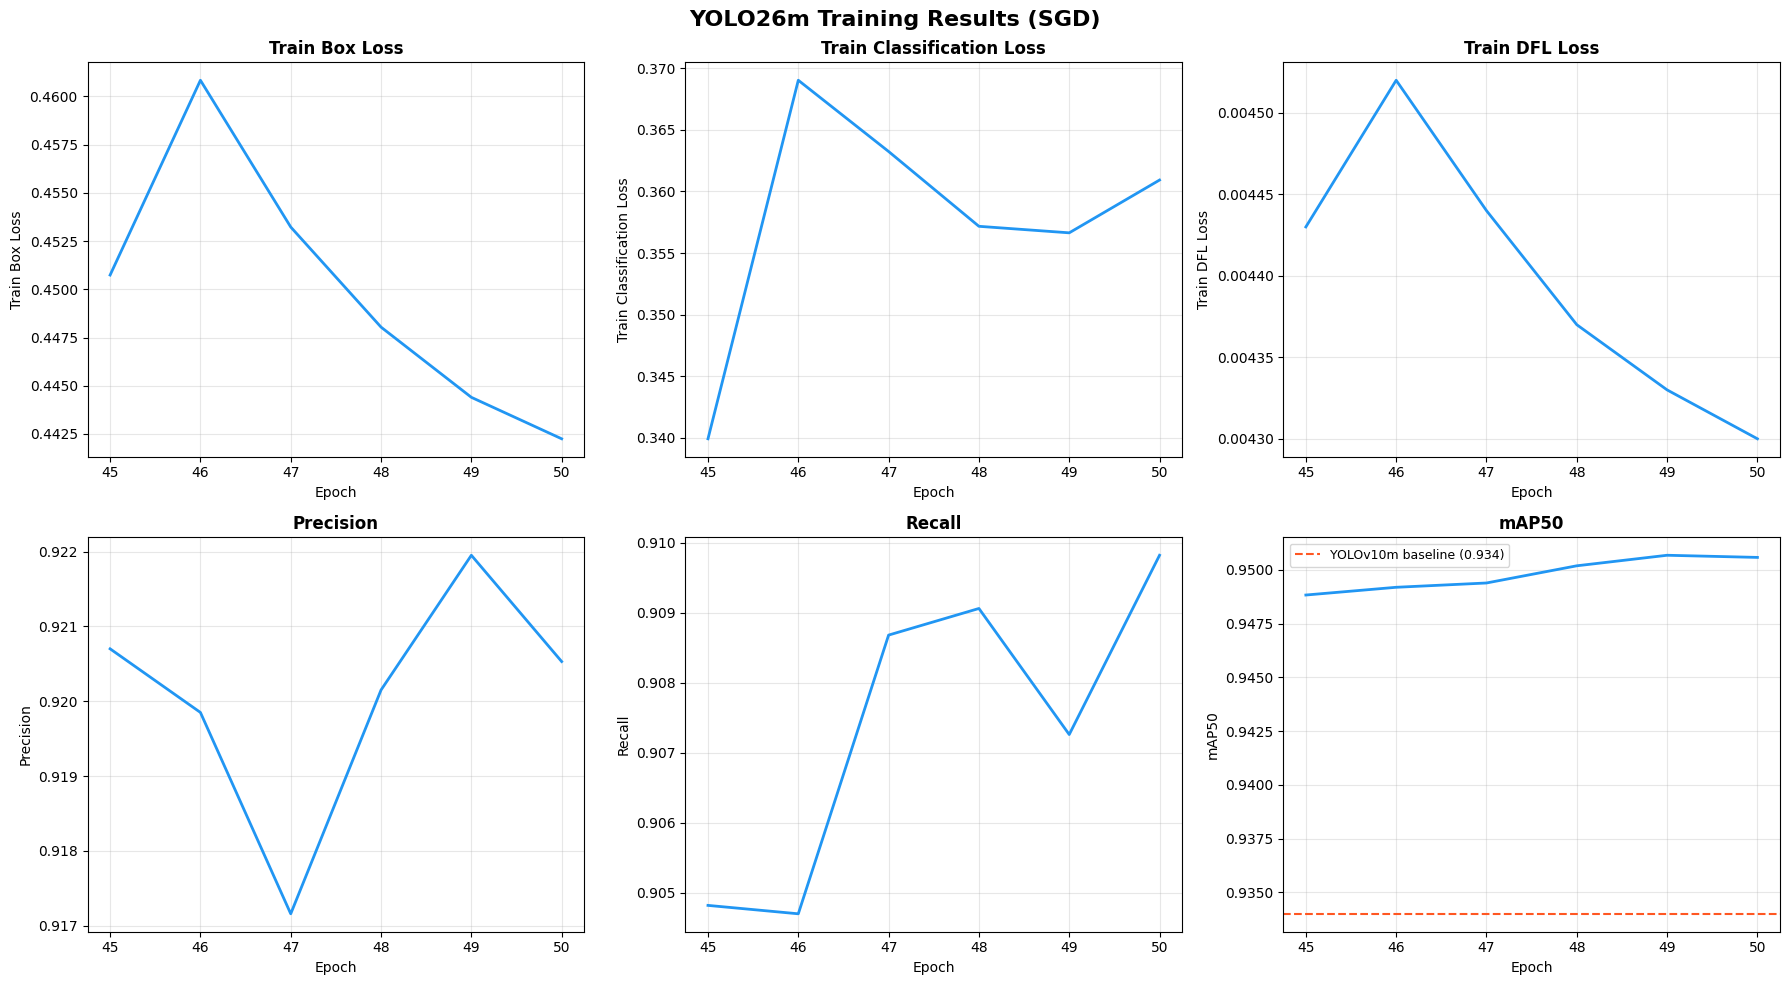

📊 Training curves saved to: /kaggle/working/runs/yolo26m_vietfood67_sgd/training_curves.png


In [11]:
# ============================================================
# 📈 TRAINING CURVES VISUALIZATION
# ============================================================

def plot_training_results(results_dir, title_suffix=""):
    """Plot training metrics from results.csv."""
    csv_path = os.path.join(results_dir, "results.csv")
    if not os.path.exists(csv_path):
        print(f"❌ results.csv not found at {csv_path}")
        return
    
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"YOLO26m Training Results {title_suffix}", fontsize=16, fontweight="bold")
    
    metrics = [
        ("train/box_loss", "Train Box Loss"),
        ("train/cls_loss", "Train Classification Loss"),
        ("train/dfl_loss", "Train DFL Loss"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)", "Recall"),
        ("metrics/mAP50(B)", "mAP50"),
    ]
    
    for idx, (col, label) in enumerate(metrics):
        ax = axes[idx // 3][idx % 3]
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linewidth=2, color="#2196F3")
            
            # Add reference line for mAP50
            if "mAP50" in col:
                ax.axhline(y=0.934, color="#FF5722", linestyle="--", linewidth=1.5,
                          label="YOLOv10m baseline (0.934)")
                ax.legend(fontsize=9)
            
            ax.set_title(label, fontsize=12, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(label)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f"Column '{col}'\nnot found", 
                   ha="center", va="center", transform=ax.transAxes)
    
    plt.tight_layout()
    save_path = os.path.join(results_dir, "training_curves.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"📊 Training curves saved to: {save_path}")


sgd_results_dir = os.path.join(TRAINING_CONFIG["project"], TRAINING_CONFIG["name"])
plot_training_results(sgd_results_dir, "(SGD)")

In [12]:
# ============================================================
# 📦 EXPORT MODEL (for integration with FoodDetector project)
# ============================================================

print("📦 Exporting best YOLO26m model to ONNX format...")

model_export = YOLO(best_sgd_path)
export_path = model_export.export(format="onnx", imgsz=640, simplify=True)
print(f"✅ ONNX model exported to: {export_path}")

# Also copy the .pt weights
pt_output = os.path.join(WORK_DIR, "YOLO26m_VietFood67_SGD_best.pt")
shutil.copy2(best_sgd_path, pt_output)
print(f"✅ PyTorch weights copied to: {pt_output}")

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE!")
print("=" * 60)
print(f"📁 All outputs are in: {WORK_DIR}")
print(f"   - Best weights (.pt):  {pt_output}")
print(f"   - ONNX model:          {export_path}")
print(f"   - Comparison CSV:      {comparison_csv_path}")
print(f"   - Training logs:       {sgd_results_dir}")
print("=" * 60)

📦 Exporting best YOLO26m model to ONNX format...
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,401,880 parameters, 0 gradients, 68.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 245ms
 Downloaded onnxruntime
Prepared 2 packages in 277ms
Installed 2 packages in 19ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.2

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.3s, saved as '/kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx' (78.1 MB)

Export complete (7.1s)
Results saved to /kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx imgsz=640 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app
✅ ONNX model exported to: /kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx
✅ PyTorch weights copied to: /kaggle/working/YOLO26m_VietFood67_SGD_best.pt

🎉 TRAINING COMPLETE!
📁 All outputs are in: /kaggle/working
   - Best weights (.pt):  /kaggle/working/YOLO26m_VietFood67_SGD_best.pt
   - ONNX model:          /kaggle/working/runs/yolo26m_vietfood67_sgd/weights/best.onnx
   - Comparison CSV:      /kaggle/working/model_compari